# ChIPnumはlog10, featuresはz-scoredで予測
pub numはlog10したあとにz-score化した

In [1]:
# load datatable
import pandas as pd
df_reg = pd.read_csv("/Users/saeko/Documents/MOCCS/important_chipseq_prediction/data/ignored_paper/df_reg_902TF_427var_log10.tsv", sep="\t")
df_reg.head()

,pub_num,ChIP_num,var1,var2,var3,var4,var5,var6,var7,var8,...,var418,var419,var420,var421,var422,var423,var424,var425,var426,var427
0,1.116860,0.301030,-1.221343,1.335732,1.266304,1.451134,-1.081191,-0.620464,1.128741,1.304912,...,1.104406,1.011349,1.212536,1.238126,1.125150,1.212249,1.125947,0.900949,0.714594,0.361582
1,2.187243,0.698970,-0.404102,-0.119716,0.966966,-0.772425,1.338718,-0.620444,1.116724,0.906000,...,0.665871,0.981769,0.933349,0.974418,0.977015,0.952512,0.855586,0.900949,0.714594,1.538638
2,2.748681,2.943989,0.118663,0.489127,0.806041,1.666712,-1.315808,-0.620462,0.301282,0.058831,...,-0.434575,-0.290427,-1.584552,-1.615123,-0.463752,-1.561771,-1.595916,-0.740499,-0.274564,-0.147543
3,0.756831,1.690196,-0.524076,0.748819,1.327742,1.620883,-1.265931,-0.620464,0.060395,0.297519,...,0.650365,0.634577,0.732693,0.740827,0.674407,0.798427,0.725416,0.844347,0.714594,0.316687
4,0.781191,0.477121,0.787040,1.178473,0.799100,1.646693,-1.294023,-0.620460,-0.075304,-0.174818,...,0.789717,0.868330,0.752055,0.690146,0.748773,0.650112,0.818241,0.617940,0.714594,-0.175999


<Axes: >

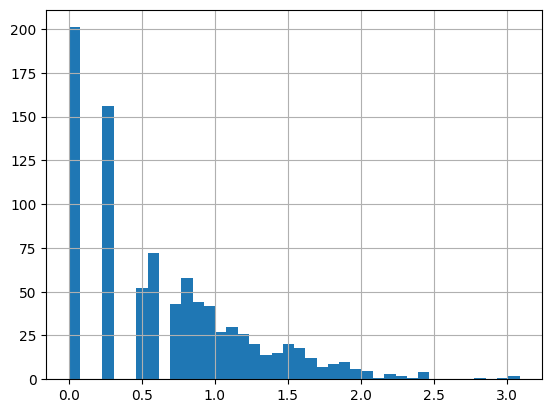

In [2]:
# histgram of pub_num, title: ChIP_seq
#df_reg['pub_num'].hist(bins=100)
df_reg['ChIP_num'].hist(bins=40)

In [3]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr
from tqdm import tqdm

In [4]:
import xgboost
print(xgboost.__version__)

2.0.0


In [5]:
features = [c for c in df_reg.columns if c != "ChIP_num"]
X = df_reg[features]
y = df_reg["ChIP_num"].values

#print(X)
#print(y)

# 1. XGBoost

In [ ]:
n_iter = 400
results = pd.DataFrame(index=df_reg.index)
importance_list = []

for i in range(n_iter):
    train_idx, test_idx = train_test_split(df_reg.index, test_size=0.1, shuffle=True, random_state=i)

    X_train = X.loc[train_idx]
    y_train = y[train_idx]
    X_test = X.loc[test_idx]
    y_test = y[test_idx]

    model = XGBRegressor(
        n_estimators=300,
        objective="reg:squarederror",
        #objective="reg:absoluteerror",
        random_state=i,
        verbosity=0#,
        #sample_weight=weights
    )
    model.fit(X_train, y_train)

    # テストデータの予測値を保存（index一致させる）
    preds = pd.Series(model.predict(X_test), index=test_idx)
    results[f"run_{i}"] = preds

    # importance を dict → Series → DataFrame に変換
    imp = pd.Series(model.feature_importances_, index=features)
    importance_list.append(imp)

# 各TFの中央値予測を集約
median_preds = results.median(axis=1, skipna=True)

# 有効なインデックスで評価
valid_idx = median_preds.dropna().index
rmse = np.sqrt(mean_squared_error(y[valid_idx], median_preds[valid_idx])) #平均二乗誤差（MSE）計算 -> 平方根でRMSEへ
corr, _ = spearmanr(y[valid_idx], median_preds[valid_idx]) #スピアマン順位相関係数, 戻り値は (corr係数, p値) 

print(f"Final RMSE: {rmse:.3f}") #小数点以下3桁で表示
print(f"Spearman correlation: {corr:.3f}") #小数点以下3桁で表示

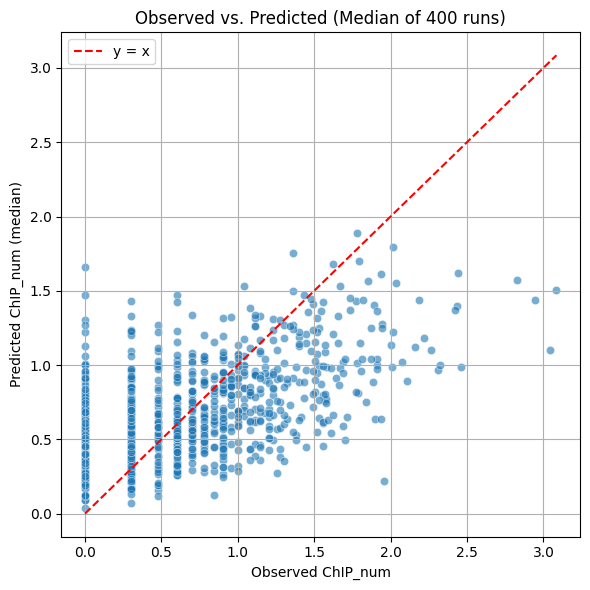

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# 実測値と予測中央値のSeriesを揃える
true_vals = pd.Series(y, index=df_reg.index).loc[valid_idx]
pred_vals = median_preds.loc[valid_idx]

# 散布図を描画
plt.figure(figsize=(6, 6))
sns.scatterplot(x=true_vals, y=pred_vals, alpha=0.6)
plt.plot([true_vals.min(), true_vals.max()],
         [true_vals.min(), true_vals.max()], color='red', linestyle='--', label='y = x')
plt.xlabel("Observed ChIP_num")
plt.ylabel("Predicted ChIP_num (median)")
plt.title("Observed vs. Predicted (Median of 400 runs)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


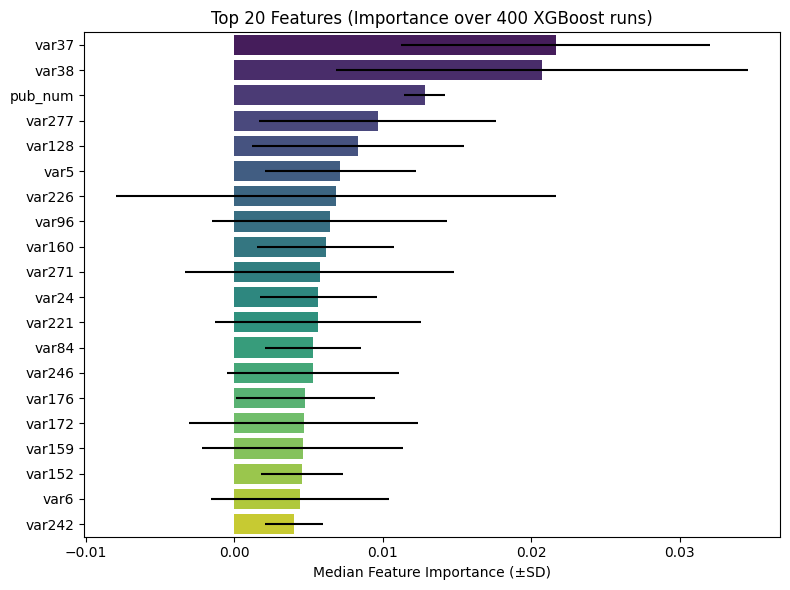

In [35]:
# importance を dict → Series → DataFrame に変換
imp = pd.Series(model.feature_importances_, index=features)
importance_list.append(imp)

# すべての反復から DataFrame 化
importance_df = pd.DataFrame(importance_list)

# 平均と標準偏差を算出
median_importance = importance_df.median().sort_values(ascending=False)
std_importance = importance_df.std()

# 上位20特徴量を可視化
top_n = 20
plt.figure(figsize=(8, 6))
sns.barplot(
    x=median_importance.iloc[:top_n],
    y=median_importance.index[:top_n],
    xerr=std_importance.loc[median_importance.index[:top_n]],
    palette="viridis"
)
plt.xlabel("Median Feature Importance (±SD)")
plt.title(f"Top {top_n} Features (Importance over {n_iter} XGBoost runs)")
plt.tight_layout()
plt.show()

In [ ]:
# save data
# resultとfeature importanceの情報を出力
# 散布図で使った予測値と実測値のペア
scatter_df = pd.DataFrame({
    "Observed_ChIP_num": y[valid_idx],
    "Predicted_ChIP_num_median": median_preds[valid_idx]
})

scatter_df.to_csv("/Users/saeko/Unmeasured/data/xgboost/rev1/scatter_data.tsv", sep="\t", index_label="TF_name")

# 特徴量重要度の統計値を保存


# 特徴量重要度の統計値（全反復）
importance_summary = pd.DataFrame({
    "Feature": median_importance.index,
    "Median_Importance": median_importance.values,
    "Std_Importance": std_importance[median_importance.index].values
})

importance_summary.to_csv("/Users/saeko/Unmeasured/data/xgboost/rev1/feature_importance_summary.tsv", sep="\t", index=False)